# Image Dithering & Halftoning Seminar Demonstrations
**Department of Computer Science - Algorithm & Programming Track**

This notebook implements and visualizes the core quantization and dithering algorithms covered in the seminar:
1. **Naïve Direct Thresholding** ($O(1)$ - Severe False Contouring)
2. **Ordered Dithering with 4x4 Bayer Matrix** ($O(1)$ - GPU-Parallel Matrix Lookup)
3. **Floyd-Steinberg Error Diffusion** ($O(N)$ - Sequential Raster Error Propagation)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot styling for clean output
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. Generate Synthetic Test Images: A smooth gradient & 3D sphere depth map
def generate_gradient_image(width=256, height=256):
    """Generates a continuous horizontal 8-bit grayscale gradient [0, 1]."""
    x = np.linspace(0, 1, width)
    return np.tile(x, (height, 1)).astype(np.float32)

def generate_sphere_image(size=256):
    """Generates a 3D sphere with ambient shading to mimic depth map quantization."""
    y, x = np.ogrid[-1:1:complex(0, size), -1:1:complex(0, size)]
    radius = np.sqrt(x**2 + y**2)
    sphere = np.cos(radius * np.pi / 2)
    sphere[radius > 1] = 0
    return np.clip(sphere, 0, 1).astype(np.float32)

gradient_img = generate_gradient_image()
sphere_img = generate_sphere_image()

print("Synthetic test images generated successfully.")

Synthetic test images generated successfully.


## 1. Naïve Direct Thresholding
- **Mechanism**: Maps continuous luminosity directly to binary states using a static cutoff $\tau = 0.5$.
- **Complexity**: $O(1)$ per pixel.
- **Artifacts**: Severe false contouring / loss of dynamic detail.

In [4]:
def direct_threshold(image: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Naïve 1-bit quantization using static thresholding."""
    return (image >= threshold).astype(np.float32)

# Apply to test images
naive_gradient = direct_threshold(gradient_img)
naive_sphere = direct_threshold(sphere_img)

## 2. Ordered Dithering (Bayer Matrix $M_4$)
- **Mechanism**: Compares per-pixel luminosity against a repeating recursive threshold lookup table.
- **Complexity**: $O(1)$ per pixel (Fully parallelizable / GPU friendly).
- **Artifacts**: Rigid geometric cross-hatch grid patterns.

In [5]:
def ordered_dither_bayer4x4(image: np.ndarray) -> np.ndarray:
    """Applies a 4x4 Bayer Matrix threshold lookup."""
    # Base Bayer Matrix M_2 -> M_4
    bayer_4x4 = (1.0 / 16.0) * np.array([
        [ 0,  8,  2, 10],
        [12,  4, 14,  6],
        [ 3, 11,  1,  9],
        [15,  7, 13,  5]
    ], dtype=np.float32)
    
    h, w = image.shape
    # Tile matrix across the image domain
    tiled_thresholds = np.tile(bayer_4x4, (h // 4 + 1, w // 4 + 1))[:h, :w]
    
    # O(1) Per-Pixel Independent Matrix Evaluation
    return (image > tiled_thresholds).astype(np.float32)

# Apply to test images
bayer_gradient = ordered_dither_bayer4x4(gradient_img)
bayer_sphere = ordered_dither_bayer4x4(sphere_img)

## 3. Floyd-Steinberg Error Diffusion
- **Mechanism**: Calculates local quantization error $e = P_{orig} - P_{quant}$ and diffuses it to neighboring unprocessed pixels using spatial weights: $[\frac{7}{16}, \frac{3}{16}, \frac{5}{16}, \frac{1}{16}]$.
- **Complexity**: $O(N)$ sequential raster dependency.
- **Artifacts**: Organic textures; minor directional worms in extreme highlights/shadows.

In [6]:
def floyd_steinberg_dither(image: np.ndarray) -> np.ndarray:
    """Applies Floyd-Steinberg spatial error diffusion."""
    img = image.copy().astype(np.float32)
    h, w = img.shape
    
    for y in range(h):
        for x in range(w):
            old_val = img[y, x]
            new_val = 1.0 if old_val >= 0.5 else 0.0
            img[y, x] = new_val
            err = old_val - new_val
            
            # Propagate error according to spatial weights
            if x + 1 < w:
                img[y, x + 1] += err * (7.0 / 16.0)
            if x - 1 >= 0 and y + 1 < h:
                img[y + 1, x - 1] += err * (3.0 / 16.0)
            if y + 1 < h:
                img[y + 1, x] += err * (5.0 / 16.0)
            if x + 1 < w and y + 1 < h:
                img[y + 1, x + 1] += err * (1.0 / 16.0)
                
    return img

# Apply to test images
fs_gradient = floyd_steinberg_dither(gradient_img)
fs_sphere = floyd_steinberg_dither(sphere_img)

## 4. Visual Comparison Matrix & Evaluation

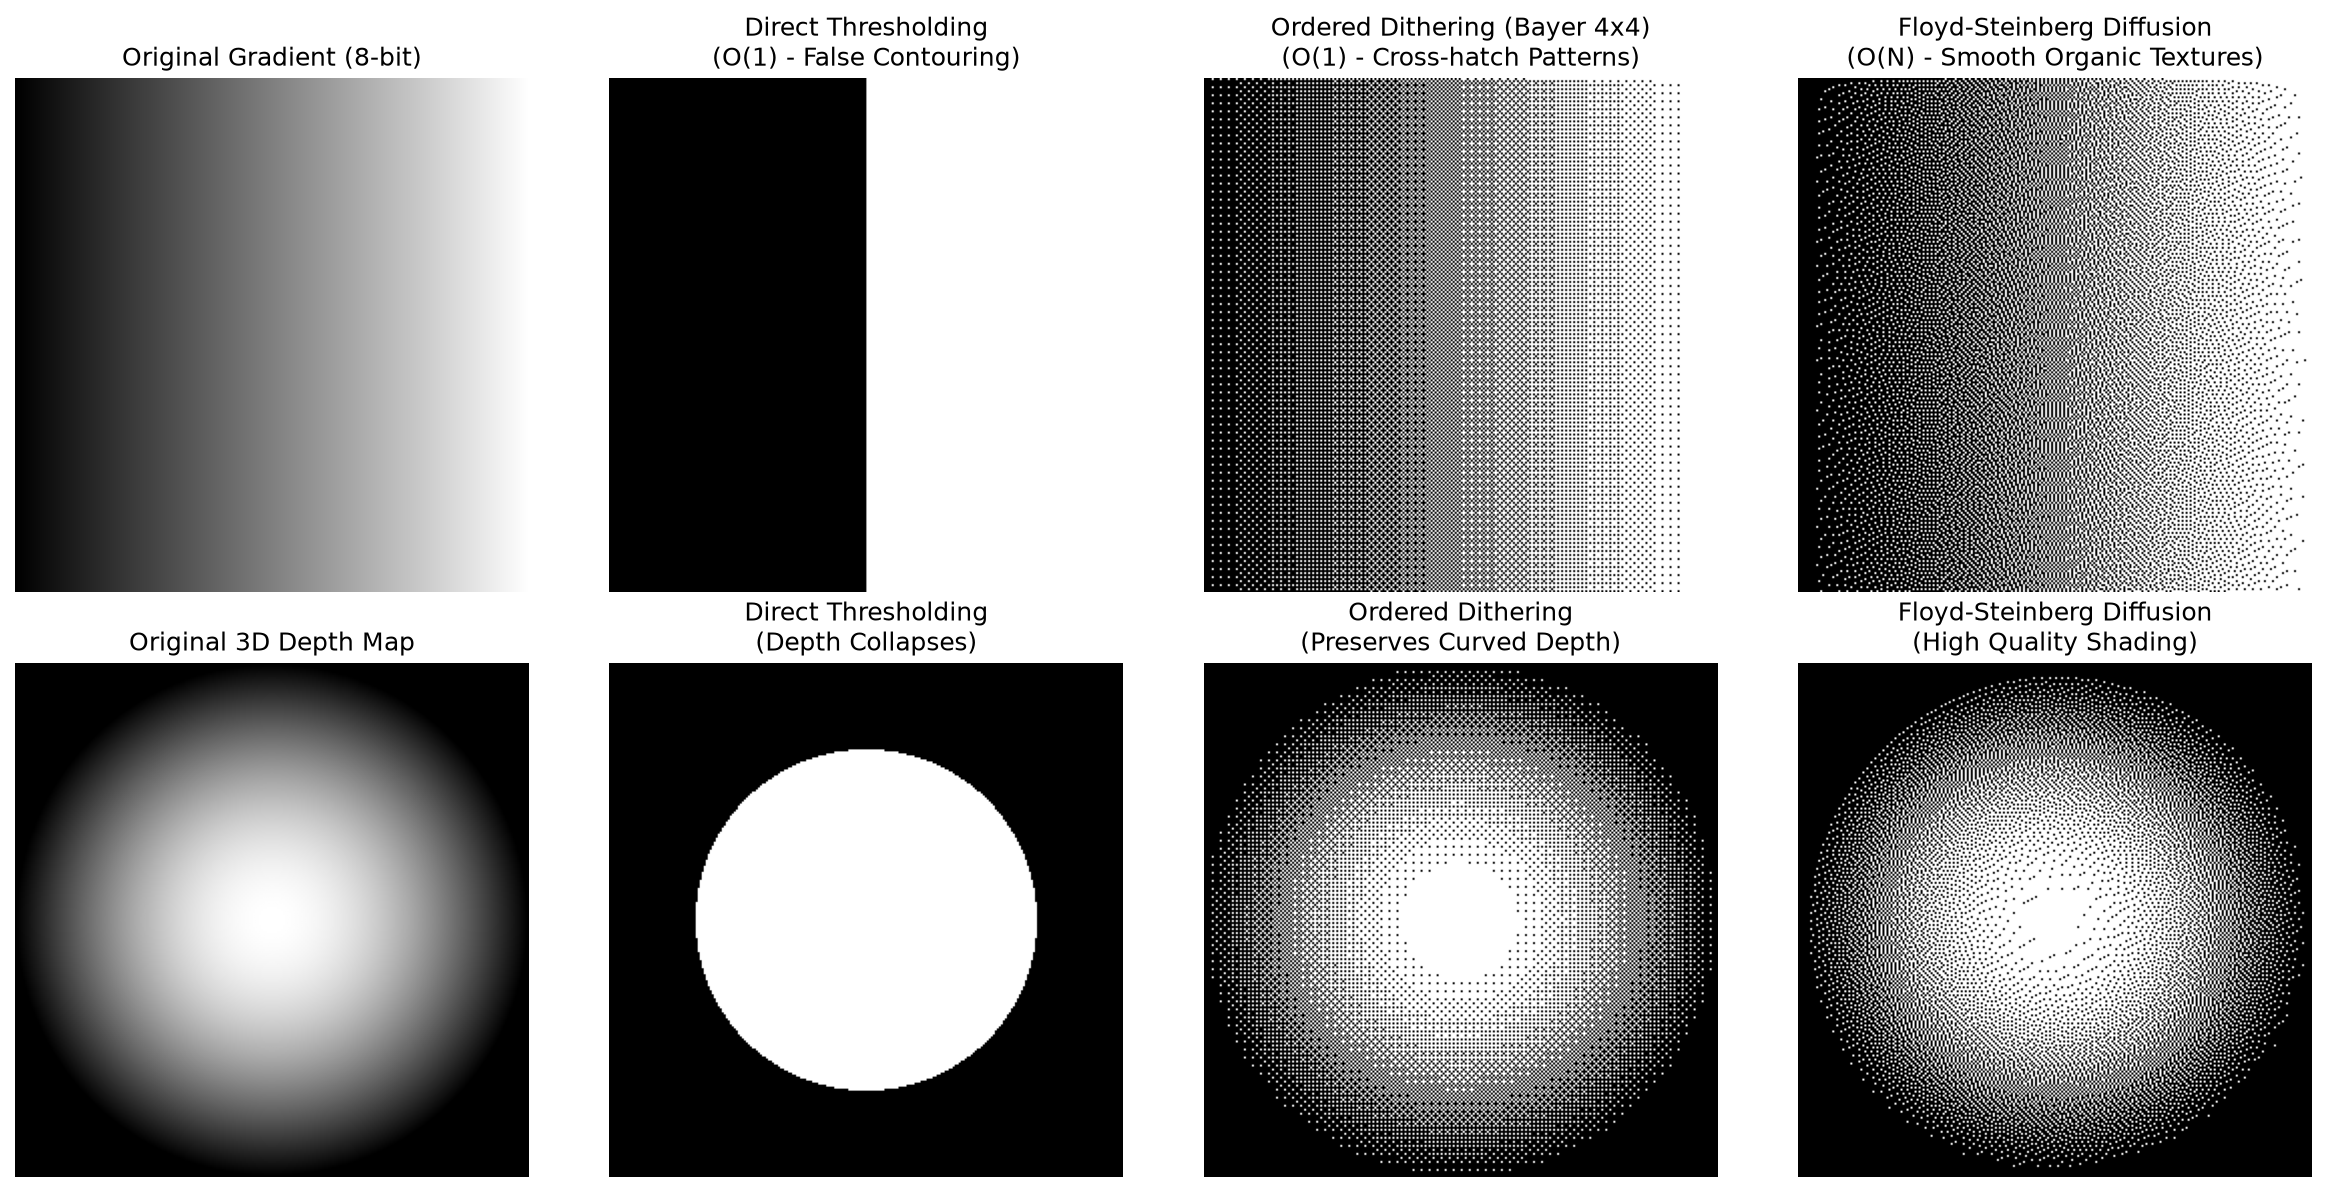

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 1: Continuous Gradients
axes[0, 0].imshow(gradient_img, cmap='gray')
axes[0, 0].set_title("Original Gradient (8-bit)")
axes[0, 1].imshow(naive_gradient, cmap='gray')
axes[0, 1].set_title("Direct Thresholding\n(O(1) - False Contouring)")
axes[0, 2].imshow(bayer_gradient, cmap='gray')
axes[0, 2].set_title("Ordered Dithering (Bayer 4x4)\n(O(1) - Cross-hatch Patterns)")
axes[0, 3].imshow(fs_gradient, cmap='gray')
axes[0, 3].set_title("Floyd-Steinberg Diffusion\n(O(N) - Smooth Organic Textures)")

# Row 2: 3D Depth Map Spheres
axes[1, 0].imshow(sphere_img, cmap='gray')
axes[1, 0].set_title("Original 3D Depth Map")
axes[1, 1].imshow(naive_sphere, cmap='gray')
axes[1, 1].set_title("Direct Thresholding\n(Depth Collapses)")
axes[1, 2].imshow(bayer_sphere, cmap='gray')
axes[1, 2].set_title("Ordered Dithering\n(Preserves Curved Depth)")
axes[1, 3].imshow(fs_sphere, cmap='gray')
axes[1, 3].set_title("Floyd-Steinberg Diffusion\n(High Quality Shading)")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()